# IV.POS.8 D1.A — V5 Decaying Floor Variants

Dataset: **4 paired triplets** (seeds 1234–1237) × 3 variants (V5-static, V5-decayexp, V5-decayepoch) + **10 R2 V5-static** baselines (seeds 1234–1243).

Artifacts from `build_d1a_artifacts.py`. Plots saved under `plots/`.


In [1]:

import json, sqlite3, math
from pathlib import Path
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import Image, display

REPO = Path('/root/arguzz')
D1A = REPO / 'a4/runs/iv_pos_8/d1a'
IV7 = REPO / 'a4/runs/iv_pos_7'
sys_path = str(IV7)
import sys
sys.path.insert(0, sys_path)

from analysis.metrics import N_MUTATIONS, _coverage_curve, _read_first_hits
from analysis.discover import discover_dbs

PLOTS = D1A / 'plots'
PLOTS.mkdir(exist_ok=True)
COLORS = {'V5': '#1f77b4', 'V5-decayexp': '#2ca02c', 'V5-decayepoch': '#d62728'}

metrics = pd.read_csv(D1A / 'd1a_metrics_table.csv')
paired = pd.read_csv(D1A / 'd1a_paired_tests.csv')
dynamics = pd.read_csv(D1A / 'd1a_floor_dynamics.csv')
summary = json.loads((D1A / 'd1a_build_summary.json').read_text())

def show_plot(fig, path):
    fig.savefig(path, dpi=120, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=str(path)))


## Plot 1 — Theoretical floor curves


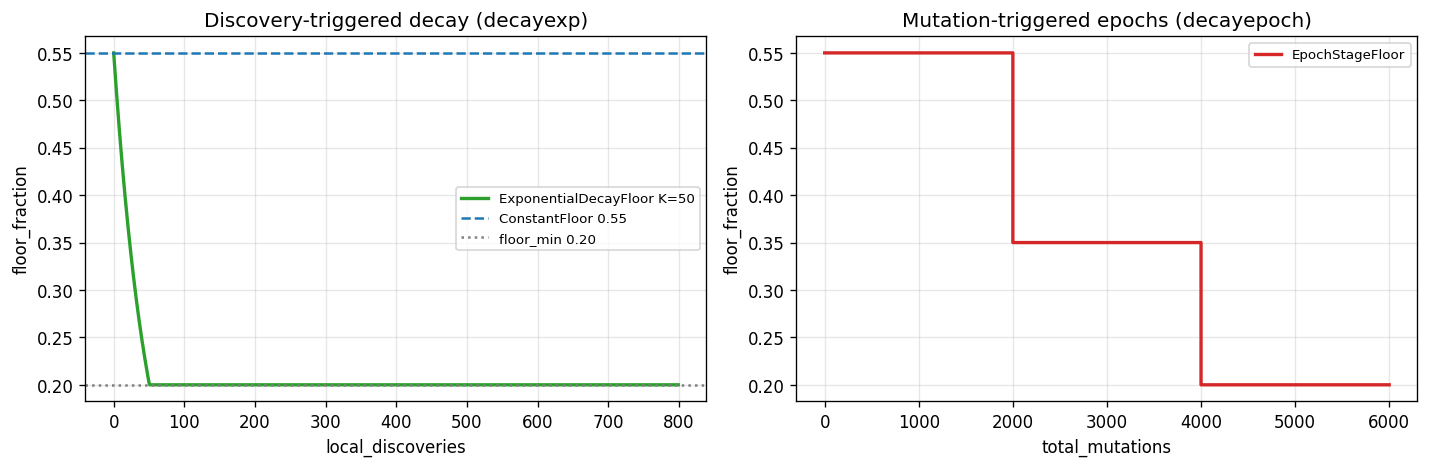

In [2]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Exponential: x = local discoveries
x_disc = np.arange(0, 800)
K = 50.0
exp_curve = np.maximum(0.20, 0.55 * np.exp(-x_disc / K))
axes[0].plot(x_disc, exp_curve, color=COLORS['V5-decayexp'], lw=2, label='ExponentialDecayFloor K=50')
axes[0].axhline(0.55, color=COLORS['V5'], ls='--', label='ConstantFloor 0.55')
axes[0].axhline(0.20, color='gray', ls=':', label='floor_min 0.20')
axes[0].set_xlabel('local_discoveries')
axes[0].set_ylabel('floor_fraction')
axes[0].set_title('Discovery-triggered decay (decayexp)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Epoch: x = total mutations
x_mut = np.arange(0, 6001)
epoch_curve = np.where(x_mut < 2000, 0.55, np.where(x_mut < 4000, 0.35, 0.20))
axes[1].step(x_mut, epoch_curve, where='post', color=COLORS['V5-decayepoch'], lw=2, label='EpochStageFloor')
axes[1].set_xlabel('total_mutations')
axes[1].set_ylabel('floor_fraction')
axes[1].set_title('Mutation-triggered epochs (decayepoch)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
show_plot(fig, PLOTS / '01_theoretical_floor_curves.png')


## Plot 2 — Cumulative coverage curves


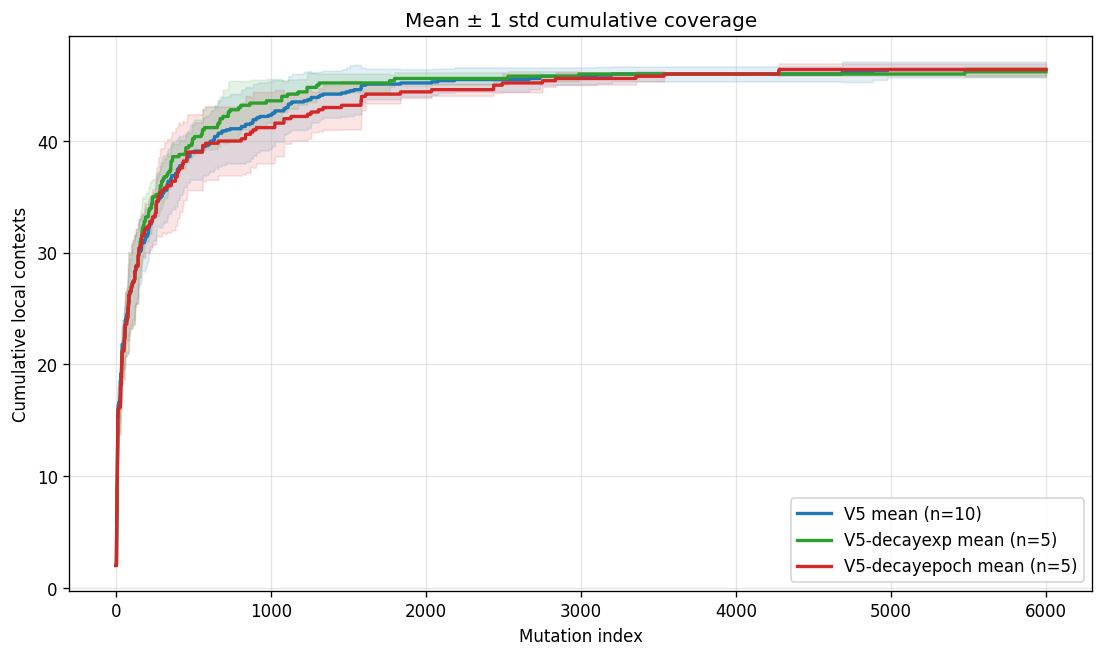

In [3]:

m_v5 = discover_dbs(IV7 / 'dbs', variants=('V5',))
m_d1a = discover_dbs(D1A / 'dbs', variants=('V5-decayexp', 'V5-decayepoch'))
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(1, N_MUTATIONS + 1)

for var, mapping in [('V5', m_v5['V5']), ('V5-decayexp', m_d1a['V5-decayexp']), ('V5-decayepoch', m_d1a['V5-decayepoch'])]:
    curves = []
    for seed, db in sorted(mapping.items()):
        with sqlite3.connect(db) as c:
            hits = _read_first_hits(c)
        curves.append(_coverage_curve(hits, n=N_MUTATIONS))
    arr = np.array(curves)
    ax.plot(x, arr.mean(0), color=COLORS[var], lw=2, label=f'{var} mean (n={len(curves)})')
    ax.fill_between(x, arr.mean(0)-arr.std(0,ddof=1), arr.mean(0)+arr.std(0,ddof=1),
                    color=COLORS[var], alpha=0.12)

ax.set_xlabel('Mutation index')
ax.set_ylabel('Cumulative local contexts')
ax.set_title('Mean ± 1 std cumulative coverage')
ax.legend()
ax.grid(alpha=0.3)
show_plot(fig, PLOTS / '02_cumulative_coverage.png')


## Plot 3 — local_context_final bar chart


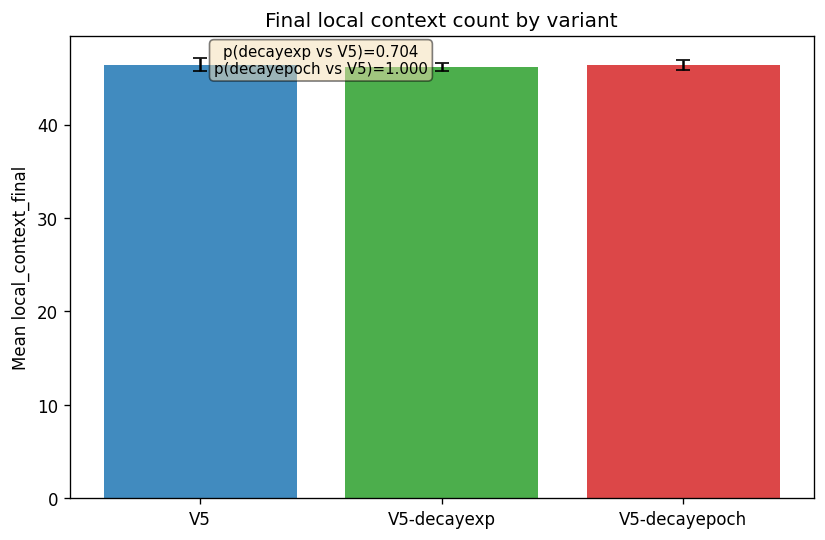

In [4]:

fig, ax = plt.subplots(figsize=(8, 5))
vars_ = ['V5', 'V5-decayexp', 'V5-decayepoch']
means = [metrics[metrics.variant==v]['local_context_final'].mean() for v in vars_]
stds = [metrics[metrics.variant==v]['local_context_final'].std(ddof=1) for v in vars_]
ax.bar(vars_, means, yerr=stds, color=[COLORS[v] for v in vars_], alpha=0.85, capsize=4)
ax.set_ylabel('Mean local_context_final')
ax.set_title('Final local context count by variant')

def pval(comp):
    row = paired[(paired.comparison==comp) & (paired.metric=='local_context_final')]
    return float(row.iloc[0]['p_value']) if len(row) else float('nan')

p_de = pval('V5-decayexp vs V5')
p_ep = pval('V5-decayepoch vs V5')
ax.text(0.5, max(means)*0.98, f'p(decayexp vs V5)={p_de:.3f}\np(decayepoch vs V5)={p_ep:.3f}',
        ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
show_plot(fig, PLOTS / '03_local_context_final.png')


## Plot 4 — Bandit mode share over time


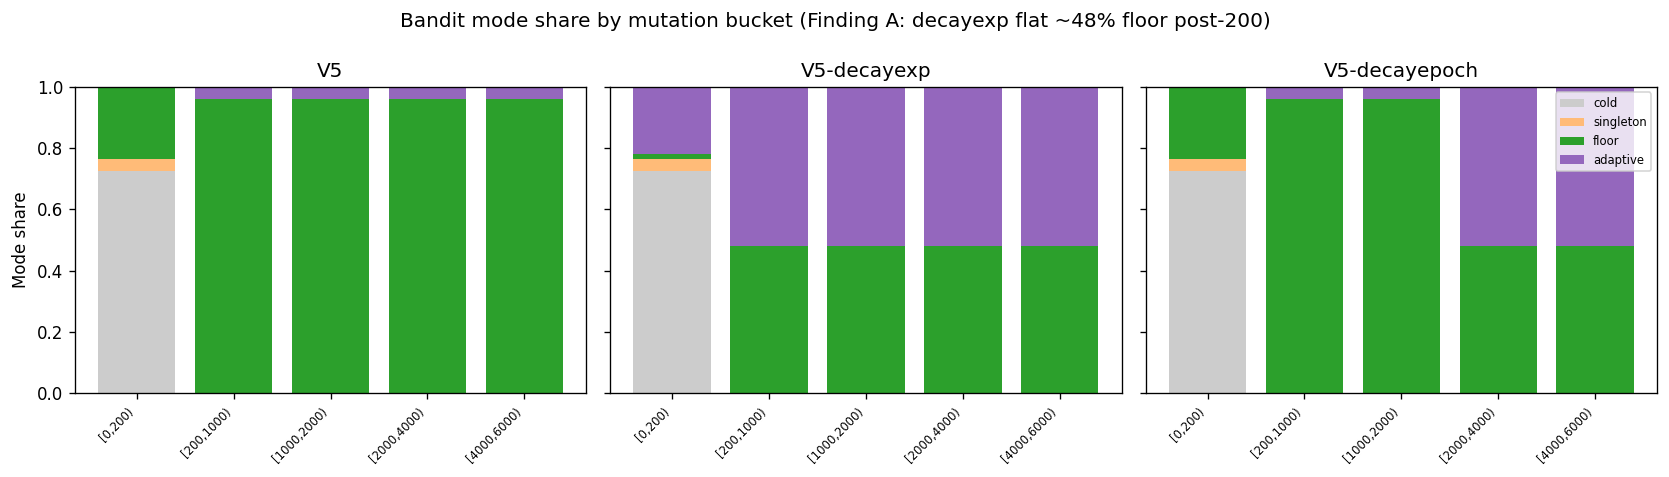

In [5]:

bucket_order = ['[0,200)', '[200,1000)', '[1000,2000)', '[2000,4000)', '[4000,6000)']
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
mode_colors = {'cold': '#cccccc', 'singleton': '#ffbb78', 'floor': '#2ca02c', 'adaptive': '#9467bd'}

for ax, var in zip(axes, ['V5', 'V5-decayexp', 'V5-decayepoch']):
    sub = dynamics[dynamics.variant == var]
    pivot = sub.groupby(['mutation_id_bucket', 'mode'])['count'].sum().unstack(fill_value=0)
    pivot = pivot.reindex(bucket_order).fillna(0)
    totals = pivot.sum(axis=1).replace(0, np.nan)
    shares = pivot.div(totals, axis=0).fillna(0)
    bottom = np.zeros(len(bucket_order))
    x = np.arange(len(bucket_order))
    for mode in ['cold', 'singleton', 'floor', 'adaptive']:
        if mode not in shares.columns:
            continue
        ax.bar(x, shares[mode].values, bottom=bottom, label=mode, color=mode_colors[mode])
        bottom += shares[mode].values
    ax.set_xticks(x)
    ax.set_xticklabels(bucket_order, rotation=45, ha='right', fontsize=7)
    ax.set_title(var)
    ax.set_ylim(0, 1)
axes[0].set_ylabel('Mode share')
axes[2].legend(loc='upper right', fontsize=7)
fig.suptitle('Bandit mode share by mutation bucket (Finding A: decayexp flat ~48% floor post-200)')
plt.tight_layout()
show_plot(fig, PLOTS / '04_mode_share_over_time.png')


## Plot 5 — Time-to-threshold strip plots


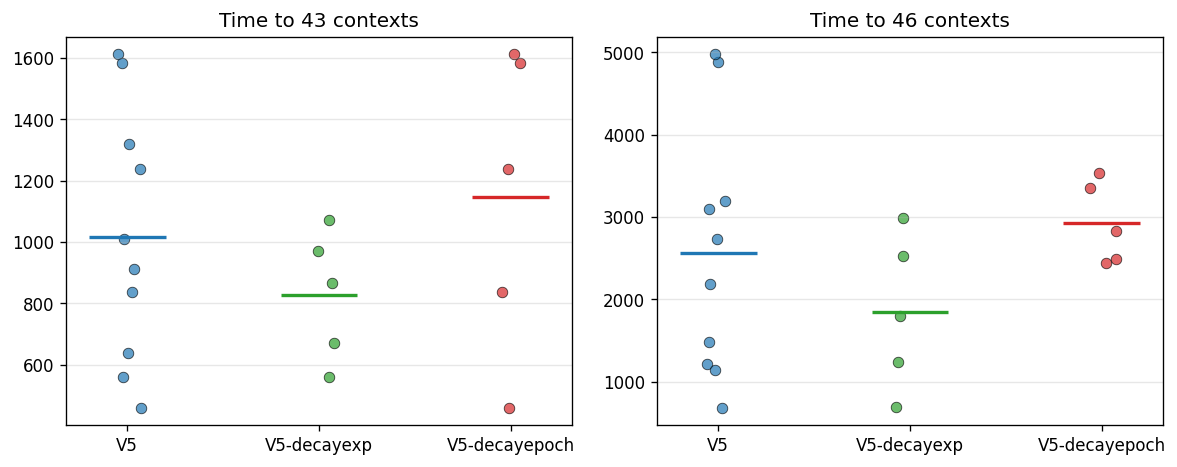

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, title in zip(axes, ['time_to_43', 'time_to_46'], ['Time to 43 contexts', 'Time to 46 contexts']):
    for i, v in enumerate(vars_):
        vals = metrics[metrics.variant==v][col].dropna().astype(float).values
        x = np.full_like(vals, i, dtype=float) + np.random.uniform(-0.08, 0.08, len(vals))
        ax.scatter(x, vals, color=COLORS[v], s=40, alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.hlines(vals.mean(), i-0.2, i+0.2, color=COLORS[v], lw=2)
    ax.set_xticks(range(len(vars_)))
    ax.set_xticklabels(vars_)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
show_plot(fig, PLOTS / '05_time_to_threshold.png')


## Findings summary


Headline numbers from d1a_build_summary.json:
  mean_local_context_final_V5: 46.4
  mean_local_context_final_V5_decayexp: 46.2
  mean_local_context_final_V5_decayepoch: 46.4
  paired_ttest_local_context_v5_vs_decayexp_p: 0.7040000000000001
  paired_ttest_local_context_v5_vs_decayepoch_p: 1.0
  floor_share_decayexp_post200: 0.48
01_theoretical_floor_curves.png 56744


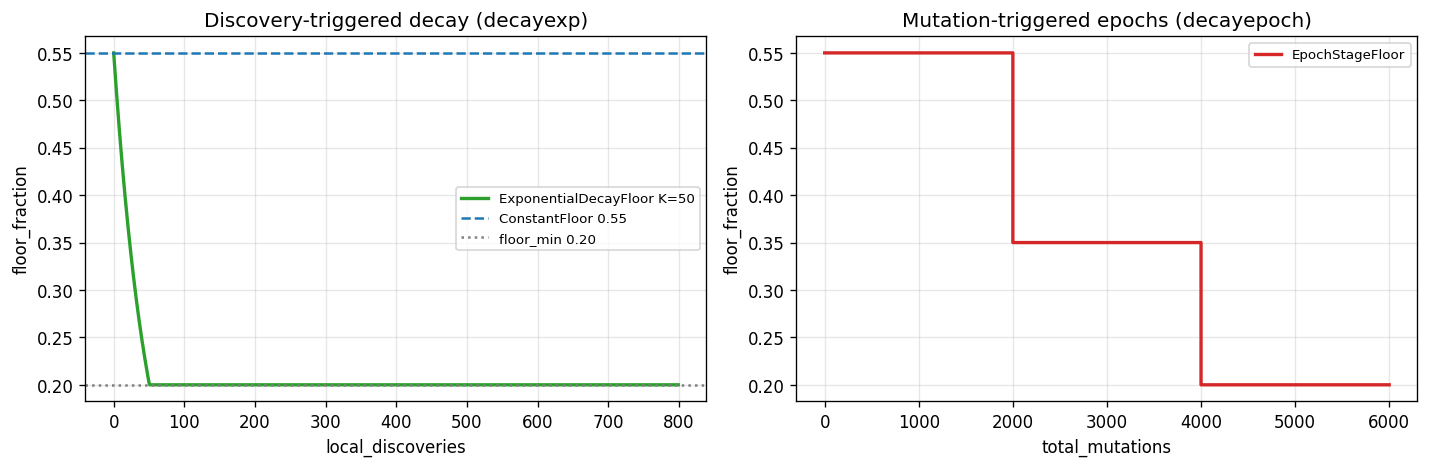

02_cumulative_coverage.png 64687


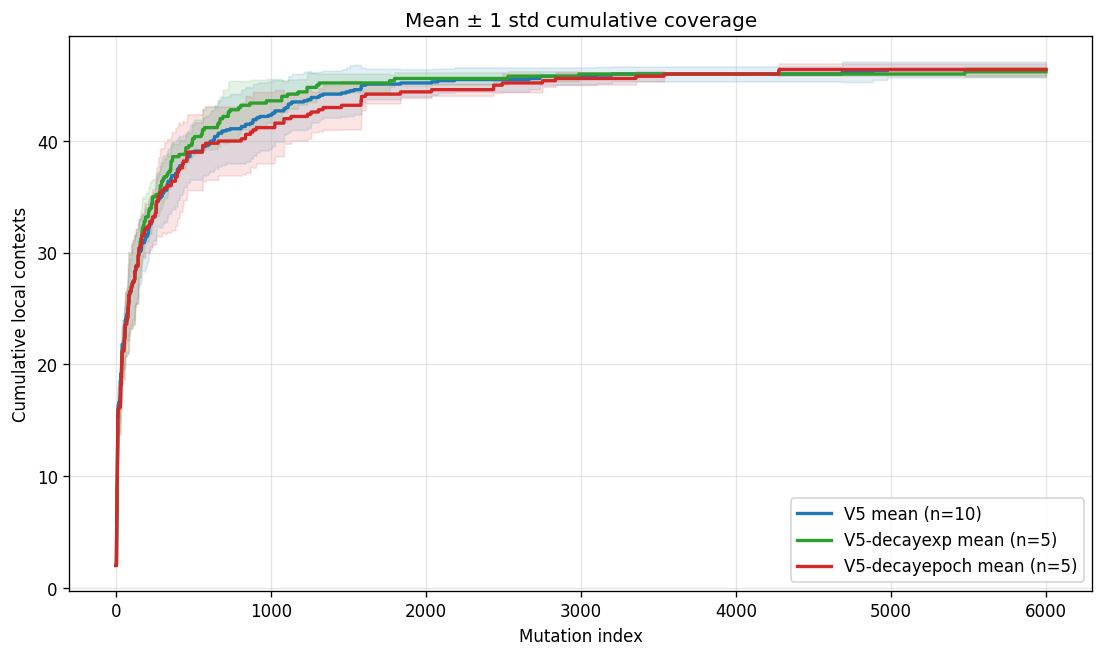

03_local_context_final.png 29704


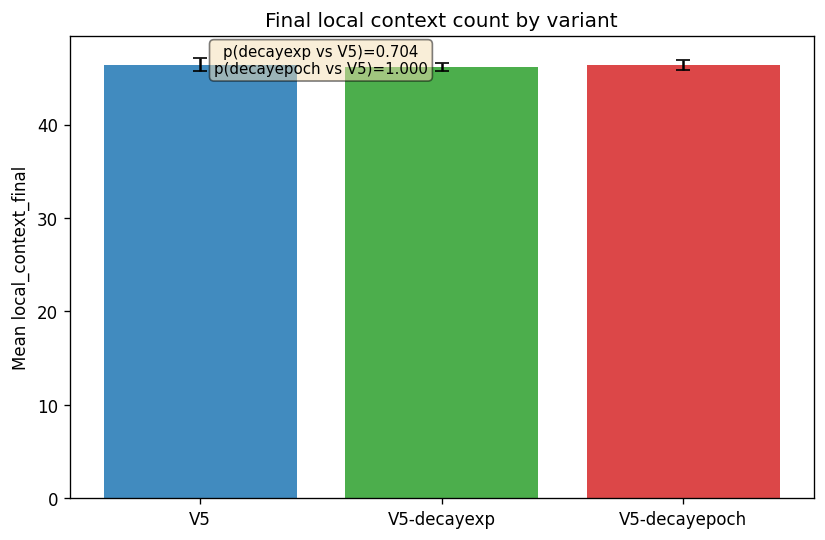

04_mode_share_over_time.png 45011


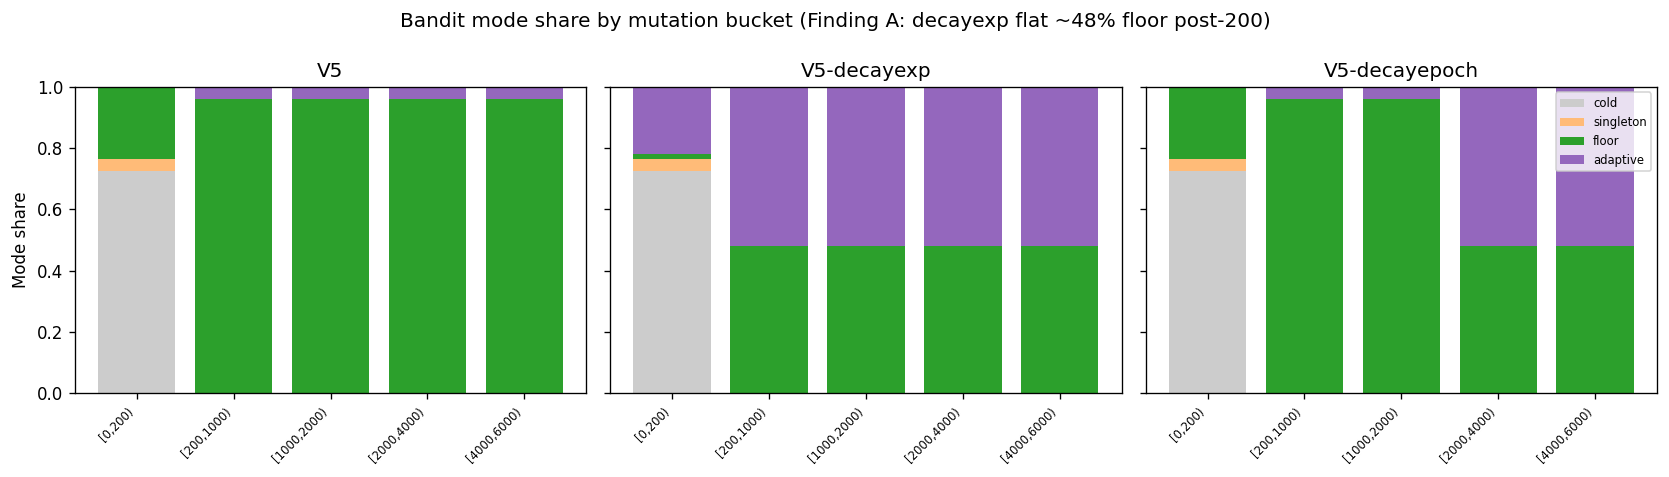

05_time_to_threshold.png 35520


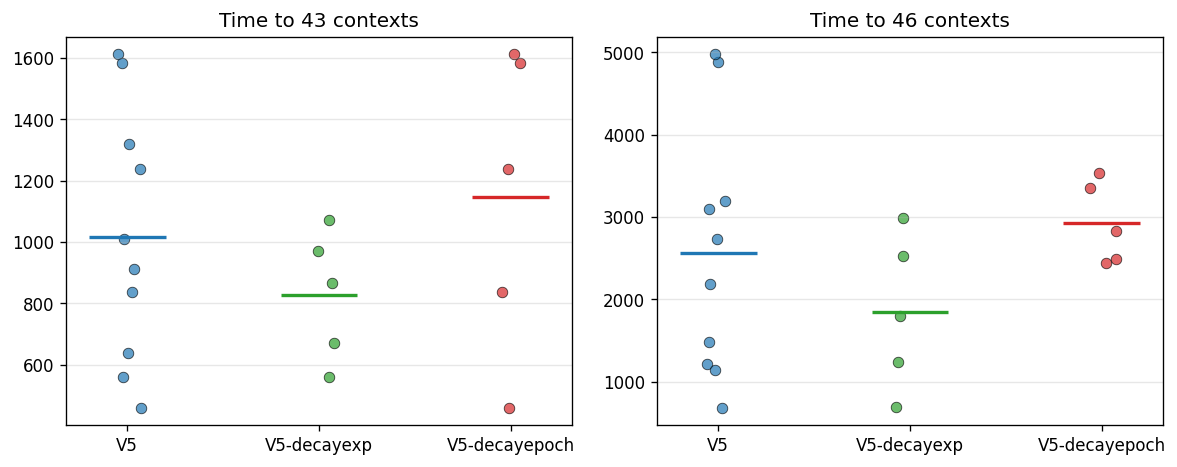

In [7]:

print('Headline numbers from d1a_build_summary.json:')
for k in ['mean_local_context_final_V5', 'mean_local_context_final_V5_decayexp',
          'mean_local_context_final_V5_decayepoch',
          'paired_ttest_local_context_v5_vs_decayexp_p',
          'paired_ttest_local_context_v5_vs_decayepoch_p',
          'floor_share_decayexp_post200']:
    print(f'  {k}: {summary[k]}')

for p in sorted(PLOTS.glob('*.png')):
    print(p.name, p.stat().st_size)
    display(Image(filename=str(p)))
